# Считывание в дата фрейм

In [8]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# Загрузка данных
df = pd.read_csv('parsing/medical_features_analysis.csv')
columns_to_skip = ['text_length_complaints', 'text_length_history', 'text_length_examination']
df_filtered = df.drop(columns=[col for col in columns_to_skip if col in df.columns], errors='ignore')

print(f"📊 Всего записей: {len(df_filtered)}")
print(f"📋 Столбцы: {list(df_filtered.columns)}")

# Добавляем CSS для горизонтальной прокрутки
display(HTML("""
<style>
.dataframe-container {
    overflow-x: auto;
    max-width: 100%;
    border: 1px solid #ccc;
    margin: 10px 0;
}
.dataframe {
    min-width: 100%;
}
</style>
"""))

# Создаем виджеты для навигации
page_size = widgets.IntSlider(value=10, min=5, max=50, step=5, description='Строк на страницу:')
page_number = widgets.IntSlider(value=0, min=0, max=max(0, (len(df_filtered)-1)//10), description='Страница:')

def display_page(page=0, size=10):
    start_idx = page * size
    end_idx = min(start_idx + size, len(df_filtered))
    
    if start_idx >= len(df_filtered):
        print("Нет данных для отображения")
        return
    
    # Отображаем с CSS оберткой для прокрутки
    display(HTML(f'<div class="dataframe-container">{df_filtered.iloc[start_idx:end_idx].to_html()}</div>'))

# Создаем интерактивный виджет
interactive_display = widgets.interactive(display_page, page=page_number, size=page_size)
display(interactive_display)

📊 Всего записей: 1798
📋 Столбцы: ['vital_temp_body', 'vital_bp_systolic', 'vital_bp_diastolic', 'vital_heart_rate', 'vital_pulse', 'vital_saturation', 'vital_resp_rate', 'lab_wbc', 'lab_crp', 'lab_glucose', 'lab_total_protein', 'has_кашель', 'intensity_кашель', 'has_температура', 'intensity_температура', 'has_одышка', 'intensity_одышка', 'has_слабость', 'intensity_слабость', 'has_головная_боль', 'intensity_головная_боль', 'has_рвота', 'intensity_рвота', 'has_насморк', 'intensity_насморк', 'has_боль_в_груди', 'intensity_боль_в_груди', 'has_аускультация', 'has_перкуссия', 'has_пальпация', 'has_отеки', 'has_цианоз', 'has_тахикардия', 'has_сатурация', 'has_артериальное_давление', 'has_анализ_крови', 'total_symptoms_count', 'total_symptoms_intensity', 'symptoms_diversity', 'filename', 'diagnosis_code', 'diagnosis_name']


interactive(children=(IntSlider(value=0, description='Страница:', max=179), IntSlider(value=10, description='С…

# Кластеризация

📊 Всего записей: 1231
🎯 Уникальных диагнозов: 20

СОЗДАНИЕ ПРОФИЛЕЙ ДИАГНОЗОВ
📈 Создано профилей для 20 диагнозов

КЛАСТЕРИЗАЦИЯ ДИАГНОЗОВ ПО ИХ МЕДИЦИНСКИМ ПРОФИЛЯМ
K=2 | Silhouette: 0.193
K=3 | Silhouette: 0.217
K=4 | Silhouette: 0.198
K=5 | Silhouette: 0.174
K=6 | Silhouette: 0.198
K=7 | Silhouette: 0.187
K=8 | Silhouette: 0.204
K=9 | Silhouette: 0.222
K=10 | Silhouette: 0.159

🎯 Оптимальное количество кластеров для диагнозов: 9

ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ ДИАГНОЗОВ


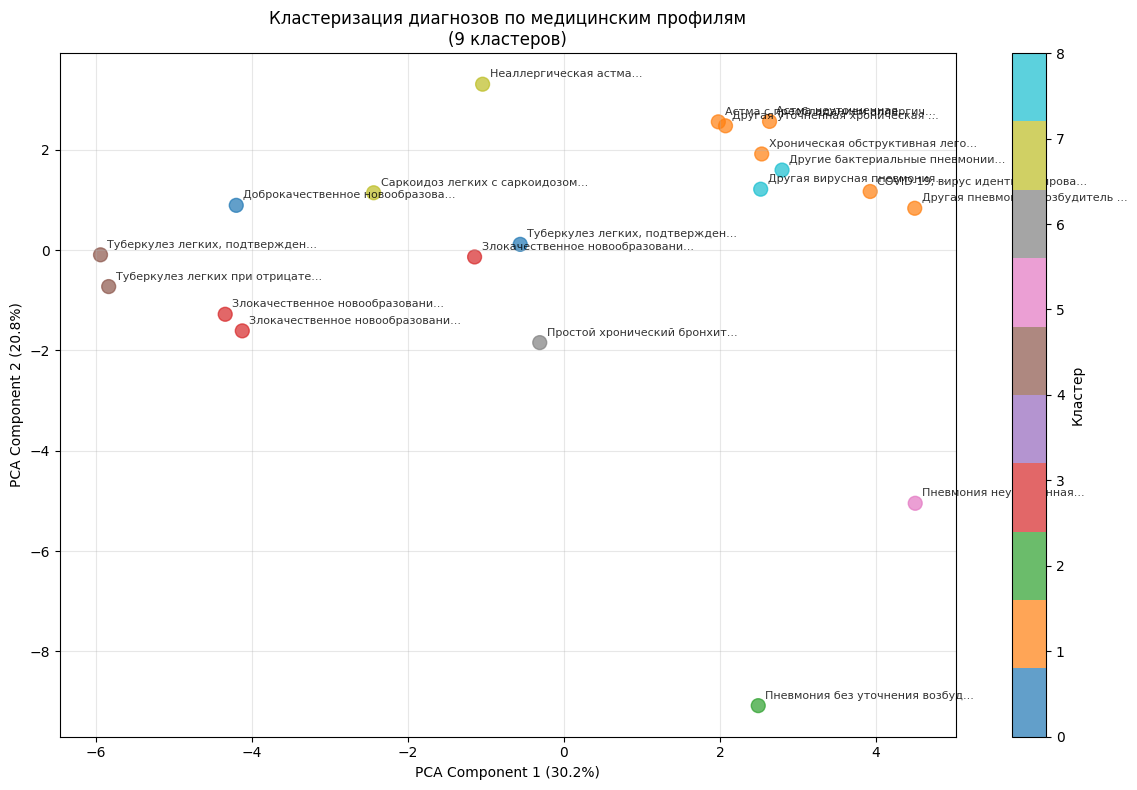

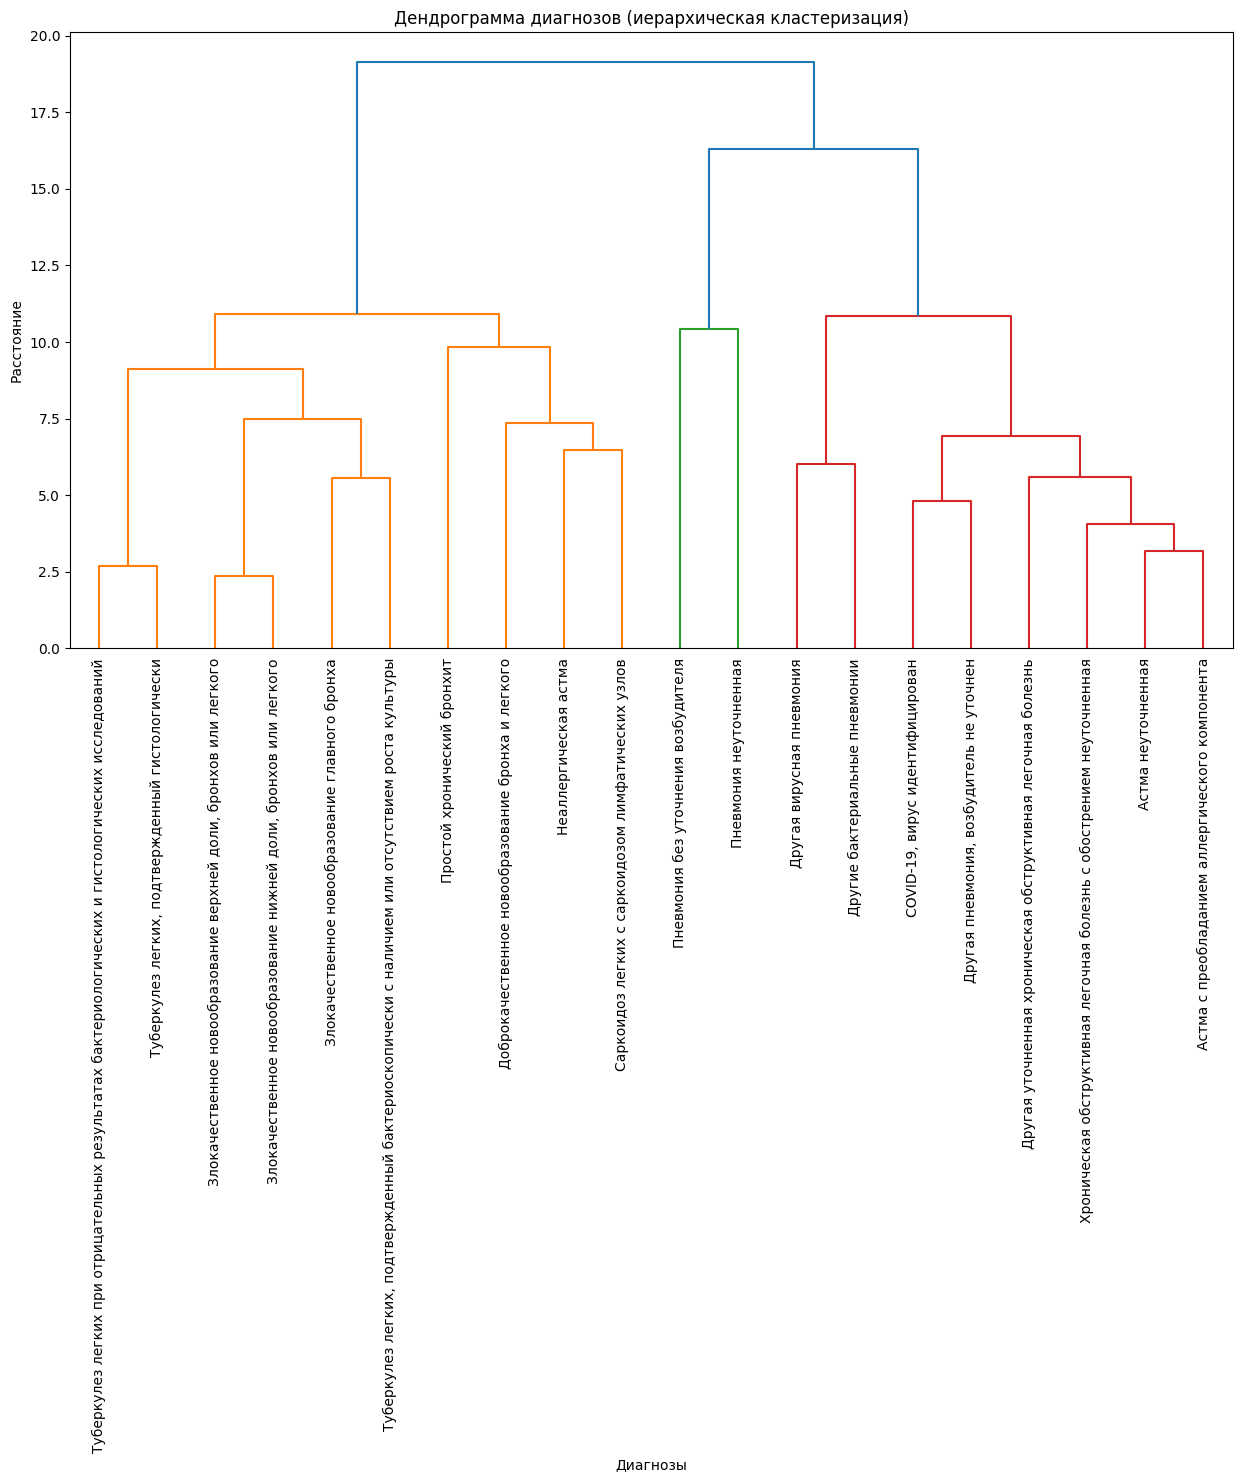


ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ ДИАГНОЗОВ

🏥 КЛАСТЕР 0:
   Диагнозы (2):
   • Доброкачественное новообразование бронха и легкого
   • Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры
   📊 Наиболее характерные признаки:
      vital_pulse: ↓ ниже среднего на 9.89
      vital_bp_diastolic: ↓ ниже среднего на 6.66
      vital_saturation: ↑ выше среднего на 6.11

🏥 КЛАСТЕР 1:
   Диагнозы (6):
   • COVID-19, вирус идентифицирован
   • Астма неуточненная
   • Астма с преобладанием аллергического компонента
   • Другая пневмония, возбудитель не уточнен
   • Другая уточненная хроническая обструктивная легочная болезнь
   • Хроническая обструктивная легочная болезнь с обострением неуточненная
   📊 Наиболее характерные признаки:
      vital_pulse: ↑ выше среднего на 12.95
      vital_heart_rate: ↑ выше среднего на 8.15
      lab_total_protein: ↓ ниже среднего на 7.58

🏥 КЛАСТЕР 2:
   Диагнозы (1):
   • Пневмония без уточнения возбудителя
   📊 Наиболее хар

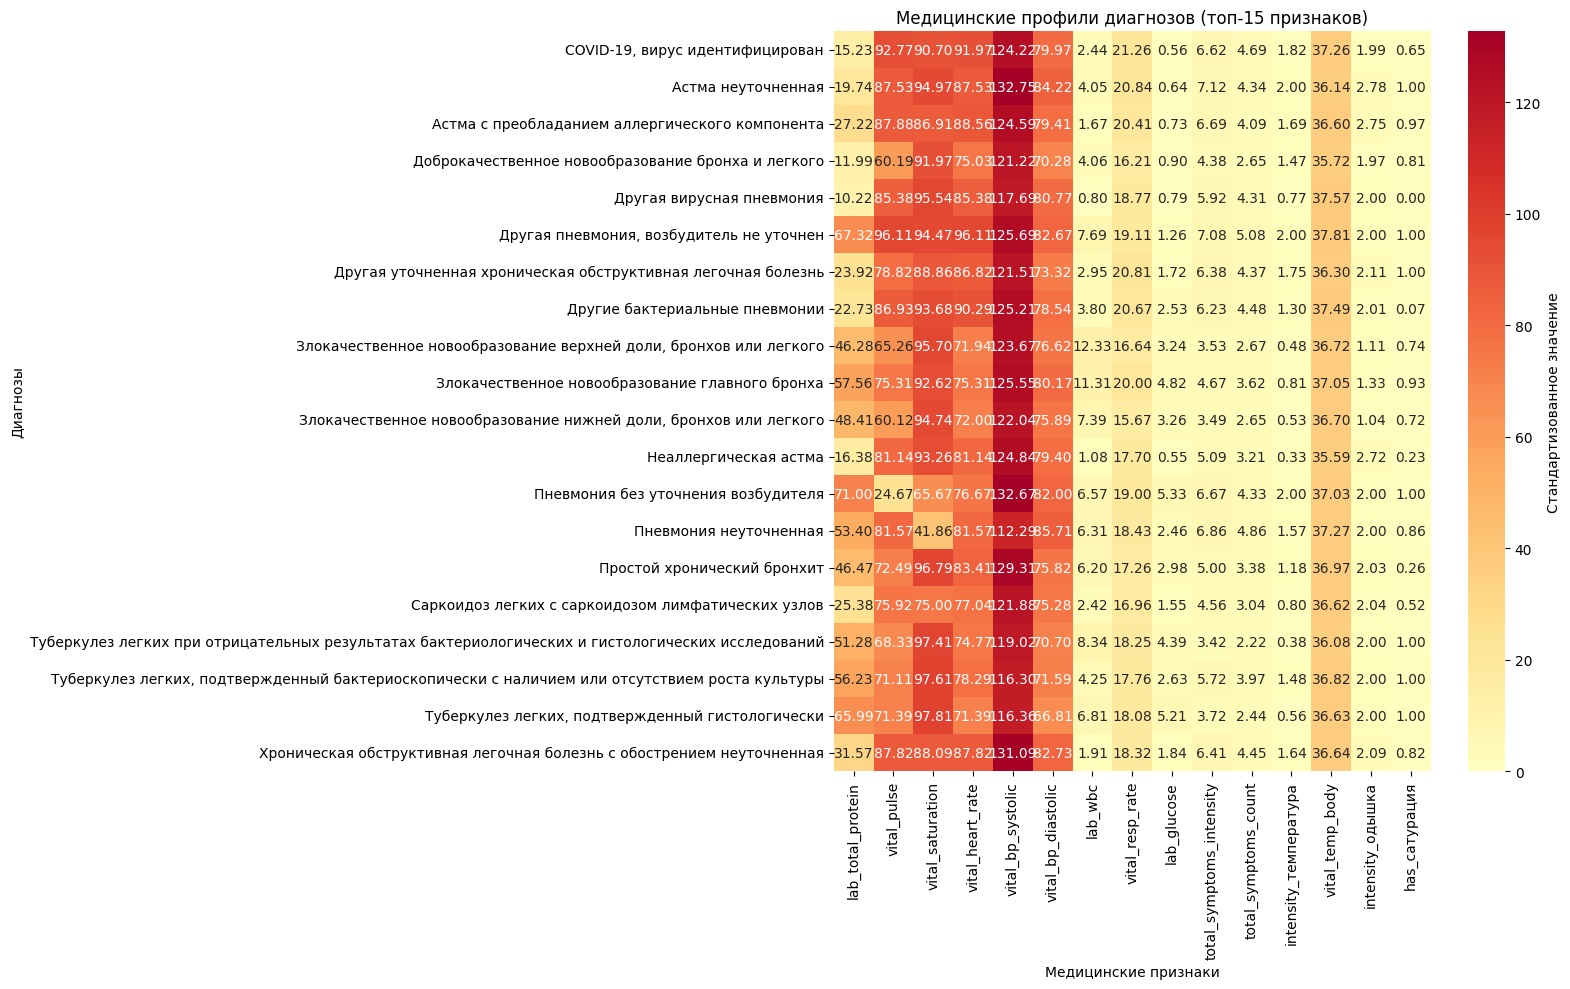

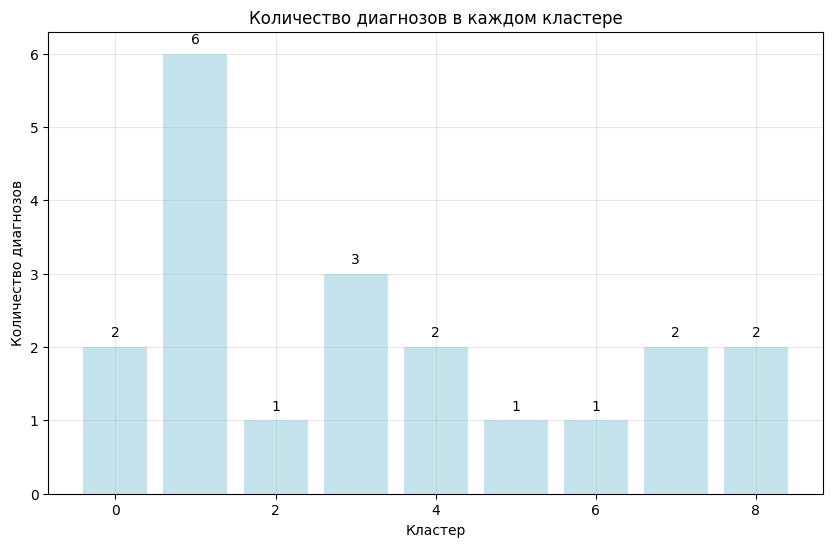


СВОДНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

📈 ОБЩАЯ СТАТИСТИКА:
   • Всего диагнозов: 20
   • Оптимальное количество групп: 9
   • Метод: K-means кластеризация медицинских профилей диагнозов

🎯 КЛЮЧЕВЫЕ ГРУППЫ ДИАГНОЗОВ:

   Группа 0 (2 диагнозов):
      - Доброкачественное новообразование бронха и легкого
      - Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры

   Группа 1 (6 диагнозов):
      - COVID-19, вирус идентифицирован
      - Астма неуточненная
      - Астма с преобладанием аллергического компонента
      - Другая пневмония, возбудитель не уточнен
      - Другая уточненная хроническая обструктивная легочная болезнь
      - Хроническая обструктивная легочная болезнь с обострением неуточненная

   Группа 2 (1 диагнозов):
      - Пневмония без уточнения возбудителя

   Группа 3 (3 диагнозов):
      - Злокачественное новообразование верхней доли, бронхов или легкого
      - Злокачественное новообразование главного бронха
      - Злокачественное 

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('parsing/medical_features_analysis.csv')
df_clean = df.dropna(subset=['diagnosis_name']).copy()

print(f"📊 Всего записей: {len(df_clean)}")
print(f"🎯 Уникальных диагнозов: {df_clean['diagnosis_name'].nunique()}")

# Создаем профили диагнозов (средние значения признаков для каждого диагноза)
print("\n" + "="*50)
print("СОЗДАНИЕ ПРОФИЛЕЙ ДИАГНОЗОВ")
print("="*50)

# Удаляем ненужные столбцы
columns_to_drop = ['filename', 'diagnosis_code', 'diagnosis_name'] + \
                 ['text_length_complaints', 'text_length_history', 'text_length_examination']
df_numeric = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns], errors='ignore')

# Заполняем пропущенные значения
if df_numeric.isnull().sum().sum() > 0:
    df_numeric = df_numeric.fillna(df_numeric.mean())

# Группируем по диагнозам и берем средние значения
diagnosis_profiles = df_clean.groupby('diagnosis_name')[df_numeric.columns].mean()
print(f"📈 Создано профилей для {len(diagnosis_profiles)} диагнозов")

# Стандартизация профилей диагнозов
scaler = StandardScaler()
diagnosis_profiles_scaled = scaler.fit_transform(diagnosis_profiles)

# Кластеризация САМИХ ДИАГНОЗОВ (не пациентов)
print("\n" + "="*50)
print("КЛАСТЕРИЗАЦИЯ ДИАГНОЗОВ ПО ИХ МЕДИЦИНСКИМ ПРОФИЛЯМ")
print("="*50)

# Тестируем разное количество кластеров для диагнозов
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = kmeans.fit_predict(diagnosis_profiles_scaled)
    
    if len(np.unique(labels)) > 1:
        score = silhouette_score(diagnosis_profiles_scaled, labels)
    else:
        score = -1
    
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette: {score:.3f}")

# Выбираем оптимальное количество кластеров
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n🎯 Оптимальное количество кластеров для диагнозов: {best_k}")

# Финальная кластеризация диагнозов
kmeans_diagnoses = KMeans(n_clusters=best_k, random_state=42, n_init=15)
diagnosis_clusters = kmeans_diagnoses.fit_predict(diagnosis_profiles_scaled)

# Добавляем кластеры к профилям диагнозов
diagnosis_profiles_clustered = diagnosis_profiles.copy()
diagnosis_profiles_clustered['cluster'] = diagnosis_clusters
diagnosis_profiles_clustered['diagnosis_name'] = diagnosis_profiles.index

# ВИЗУАЛИЗАЦИЯ 1: Кластеры диагнозов в 2D пространстве
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ ДИАГНОЗОВ")
print("="*50)

pca = PCA(n_components=2)
diagnosis_pca = pca.fit_transform(diagnosis_profiles_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(diagnosis_pca[:, 0], diagnosis_pca[:, 1], 
                     c=diagnosis_clusters, cmap='tab10', s=100, alpha=0.7)

# Добавляем названия диагнозов
for i, diagnosis in enumerate(diagnosis_profiles.index):
    plt.annotate(diagnosis[:30] + "...", 
                (diagnosis_pca[i, 0], diagnosis_pca[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'Кластеризация диагнозов по медицинским профилям\n({best_k} кластеров)')
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ 2: Дендрограмма диагнозов
plt.figure(figsize=(15, 8))
Z = linkage(diagnosis_profiles_scaled, method='ward')
dendrogram(Z, labels=diagnosis_profiles.index, leaf_rotation=90, leaf_font_size=10)
plt.title('Дендрограмма диагнозов (иерархическая кластеризация)')
plt.xlabel('Диагнозы')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

# АНАЛИЗ РЕЗУЛЬТАТОВ - ИСПРАВЛЕННАЯ ВЕРСИЯ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ ДИАГНОЗОВ")
print("="*60)

# Группируем диагнозы по кластерам
cluster_groups = diagnosis_profiles_clustered.groupby('cluster')

# Вычисляем общее среднее по всем диагнозам (исправленная строка)
overall_mean = diagnosis_profiles.mean()

for cluster_num in range(best_k):
    cluster_diagnoses = cluster_groups.get_group(cluster_num)
    
    print(f"\n🏥 КЛАСТЕР {cluster_num}:")
    print(f"   Диагнозы ({len(cluster_diagnoses)}):")
    for diagnosis in cluster_diagnoses['diagnosis_name']:
        print(f"   • {diagnosis}")
    
    # Анализ характеристик кластера
    cluster_data = cluster_diagnoses.drop(['cluster', 'diagnosis_name'], axis=1)
    cluster_mean = cluster_data.mean()
    
    # Признаки, которые наиболее отличаются от среднего
    diff = (cluster_mean - overall_mean).abs().sort_values(ascending=False)
    
    # Фильтруем признаки с валидными значениями (без NaN)
    valid_diff = diff.dropna()
    
    if len(valid_diff) > 0:
        top_features = valid_diff.head(3)
        
        print(f"   📊 Наиболее характерные признаки:")
        for feature, value in top_features.items():
            direction = "↑ выше" if cluster_mean[feature] > overall_mean[feature] else "↓ ниже"
            print(f"      {feature}: {direction} среднего на {abs(value):.2f}")
    else:
        print(f"   📊 Недостаточно данных для анализа признаков")

# ВИЗУАЛИЗАЦИЯ 3: Heatmap медицинских профилей диагнозов
print("\n" + "="*50)
print("HEATMAP МЕДИЦИНСКИХ ПРОФИЛЕЙ ДИАГНОЗОВ")
print("="*50)

# Выбираем топ-15 самых информативных признаков (без NaN)
feature_variance = diagnosis_profiles.std().sort_values(ascending=False)
# Фильтруем только признаки без NaN значений
valid_features = feature_variance.dropna()
top_features = valid_features.head(15).index

plt.figure(figsize=(16, 10))
sns.heatmap(diagnosis_profiles[top_features], 
            annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            cbar_kws={'label': 'Стандартизованное значение'})
plt.title('Медицинские профили диагнозов (топ-15 признаков)')
plt.ylabel('Диагнозы')
plt.xlabel('Медицинские признаки')
plt.tight_layout()
plt.show()

# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: Размеры кластеров
plt.figure(figsize=(10, 6))
cluster_sizes = diagnosis_profiles_clustered['cluster'].value_counts().sort_index()
plt.bar(cluster_sizes.index, cluster_sizes.values, color='lightblue', alpha=0.7)
plt.xlabel('Кластер')
plt.ylabel('Количество диагнозов')
plt.title('Количество диагнозов в каждом кластере')
for i, v in enumerate(cluster_sizes.values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.show()

# СВОДНЫЕ ВЫВОДЫ
print("\n" + "="*60)
print("СВОДНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*60)

print(f"\n📈 ОБЩАЯ СТАТИСТИКА:")
print(f"   • Всего диагнозов: {len(diagnosis_profiles)}")
print(f"   • Оптимальное количество групп: {best_k}")
print(f"   • Метод: K-means кластеризация медицинских профилей диагнозов")

print(f"\n🎯 КЛЮЧЕВЫЕ ГРУППЫ ДИАГНОЗОВ:")
for cluster_num in range(best_k):
    cluster_diagnoses = cluster_groups.get_group(cluster_num)['diagnosis_name'].tolist()
    print(f"\n   Группа {cluster_num} ({len(cluster_diagnoses)} диагнозов):")
    for diagnosis in cluster_diagnoses:
        print(f"      - {diagnosis}")



# Анализ качества кластеризации
print(f"\n🔍 КАЧЕСТВО КЛАСТЕРИЗАЦИИ:")
print(f"   • Silhouette Score: {max(silhouette_scores):.3f}")
print(f"   • Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.1%}")
print(f"   • Распределение по кластерам: {dict(cluster_sizes)}")